In [39]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [40]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [41]:
import os
os.environ["KERAS_BACKEND"] = "jax"

import bayesflow as bf

In [42]:
from simulators.benchmarks import DDM

In [64]:
num_obs = 500
epochs = 500
batch_size = 32
batches_per_epoch = 500
summary_dim = 64
seed_dim = 128
# num_train = 10000
# num_val = 100

### Workflow

In [65]:
simulator = DDM()

In [66]:
samples = simulator.sample(batch_size=batch_size)

In [67]:
adapter = (
    bf.Adapter()
    .convert_dtype("float64", "float32")
    .drop(["decay"])
    .concatenate(["v", "a", "tau", "s_v", "s_tau"], axis=-1, into="inference_variables")
    .concatenate(["rts", "choices"], into="summary_variables")
)

In [68]:
summary_network = bf.networks.SetTransformer(summary_dim=summary_dim, seed_dim=seed_dim)
inference_network = bf.networks.FlowMatching()

In [69]:
workflow = bf.BasicWorkflow(
    inference_network=inference_network,
    summary_network=summary_network,
    simulator=simulator,
    adapter=adapter,
    checkpoint_filepath=f"../checkpoints/ddm_online_{epochs}_{summary_dim}_{seed_dim}.ckpt",
)

In [70]:
validation_data = workflow.simulate(500)

In [ ]:
history = workflow.fit_online(
    epochs=epochs,
    batch_size=batch_size,
    num_batches_per_epoch=batches_per_epoch,
    validation_data=validation_data
)

INFO:bayesflow:Fitting on dataset instance of OnlineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/500
500/500 ━━━━━━━━━━━━━━━━━━━━ 36s 49ms/step - loss: 2.5886 - val_loss: 1.1999
Epoch 2/500
266/500 ━━━━━━━━━━━━━━━━━━━━ 9s 42ms/step - loss: 1.3485 

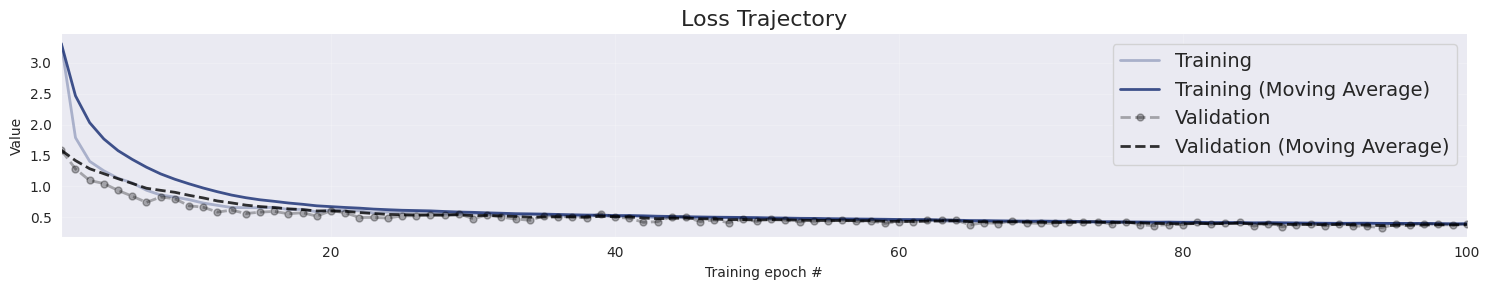

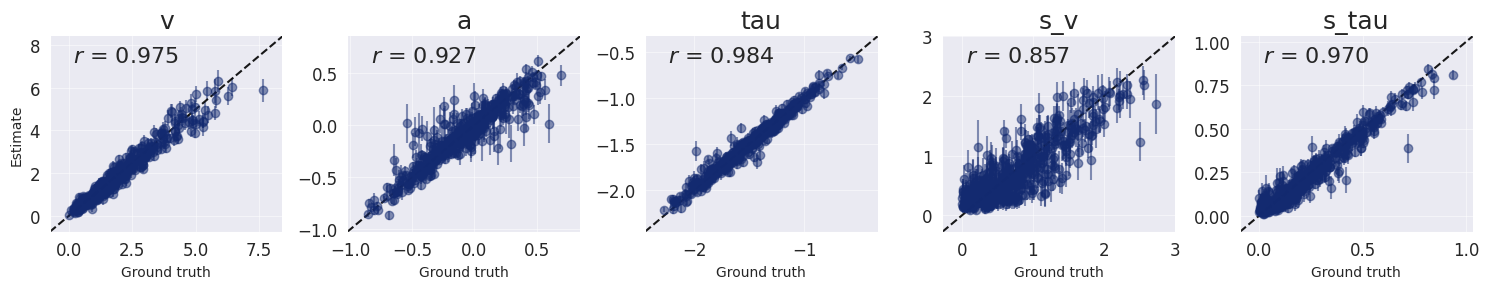

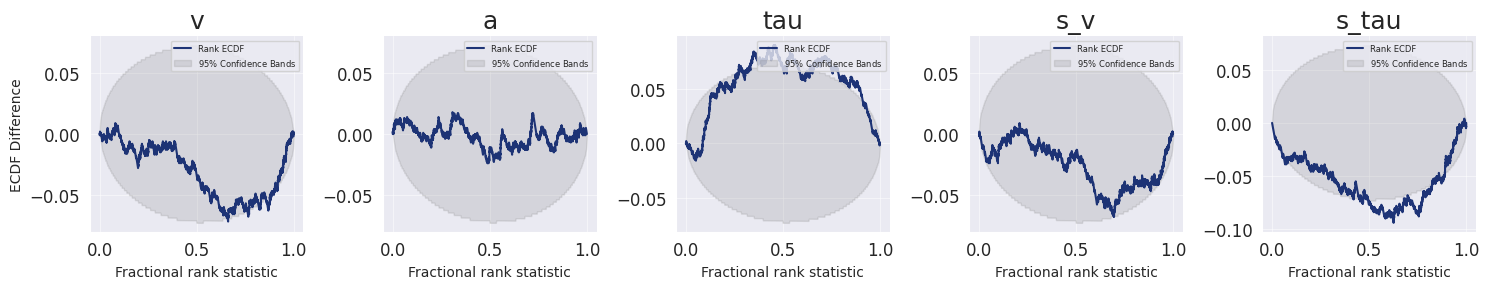

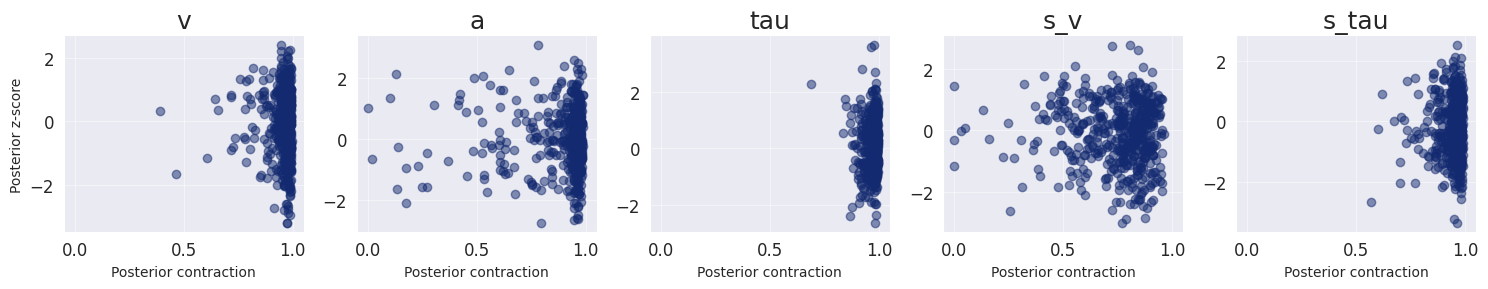

In [38]:
fig = workflow.plot_default_diagnostics(
    test_data=validation_data,
    variable_names=["v", "a", "tau", "s_v", "s_tau"],
    loss_kwargs={"figsize": (15, 3), "label_fontsize": 10},
    recovery_kwargs={"figsize": (15, 3), "label_fontsize": 10},
    calibration_ecdf_kwargs={"figsize": (15, 3), "legend_fontsize": 6, "difference": True, "label_fontsize": 10},
    z_score_contraction_kwargs={"figsize": (15, 3), "label_fontsize": 10}
)